# **Week 6 : Denoising Autoencoder Assignment on MNIST Dataset**

### **Problem Statement** : Build a deep learning model that can remove noise from images using an autoencoder on MNIST

## **Steps to Run The Notebook:**
**Step 1: Download the Data**
Download the dataset archive from Kaggle: https://www.kaggle.com/datasets/awsaf49/mnist-dataset .

Make sure the file is named exactly archive.zip.

**Step 2: Upload to Absolute Root (/)**
Open the Files panel on the left sidebar in Google Colab.

Click the "Up a directory" icon (the folder with the up arrow) at the top of the panel to move out of /content/ and into the absolute root (/).

Verification: You are in the right spot if you see system folders like sys, tmp, usr, and var.

Click the Upload icon and upload your archive.zip directly here.

**Step 3: Extract and Run**
Run Cell with command (!unzip -q /archive.zip).

CRITICAL: If a text prompt pops up asking to replace files, click the input box, type a capital A (for All), and press Enter.

Run the rest of the cells in order. (Ensure Colab's GPU is active; training takes ~1–2 minutes per model).

In [ ]:
!unzip -q /archive.zip

replace mnist_png/testing/0/1094.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## **Section 1: Environment Setup & Reproducibility**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configure device selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


- **Deterministic Seeding:** Setting manual seeds for both NumPy and PyTorch ensures consistent initializations so my results stay fully reproducible.
- **Hardware Acceleration:** The dynamic CUDA device check automatically switches the workload to the Colab GPU, accelerating our tensor operations.
- **Pipeline Cleanliness:** Isolating the core dependencies upfront keeps the runtime clean and prevents library conflicts later in the notebook.

## **Section 2: Data Preparation & Local Loading**

In [ ]:
# Define transform pipeline to convert images to grayscale, then tensors and normalize to [0.0, 1.0]
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Load the training and testing data
train_dataset = datasets.ImageFolder(root='./mnist_png/training', transform=transform)
test_dataset = datasets.ImageFolder(root='./mnist_png/testing', transform=transform)

# Initialize PyTorch DataLoaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")

Training samples: 60000, Testing samples: 9992


- **Target Scaling:** Normalizing the pixel ranges to [0.0, 1.0] inside the transform pipeline prevents gradient issues during backpropagation.
- **Structure Matching:** Using `ImageFolder` paired with `Grayscale(1)` maps our local folder structure directly to native 1-channel MNIST configurations.
- **Batch Management:** Keeping shuffle active on the train loader prevents the model from bias-memorizing order patterns within the local subfolders.

### **Subsection 2.1: Target Noise Generation Pipeline**

In [ ]:
def add_noise(images, noise_factor=0.5):
    """
    Injects random Gaussian noise into the images.
    """
    # Generate Gaussian noise matching the shape of the input images
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise

    # Force corrupted pixels to stay within the normalized [0.0, 1.0] boundaries
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)

    return noisy_images

- **Signal Corruption:** Injecting Gaussian noise with a baseline factor of 0.5 heavily distorts the numbers while still keeping the core structures visible.
- **Boundary Clamping:** Using `torch.clamp` is essential because random noise pushes pixel values beyond the valid boundary limits of 0 and 1.
- **Activation Alignment:** Keeping the noisy range locked between 0.0 and 1.0 ensures compatibility with the final Sigmoid layer in our decoders.

## **Section 3: Baseline Architecture — Linear Autoencoder (FFNN)**

In [ ]:
class LinearDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(LinearDenoisingAutoencoder, self).__init__()
        # Encoder: 784 (28x28) -> 64
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 64),
            nn.ReLU(True)
        )
        # Decoder: 64 -> 784 (28x28)
        self.decoder = nn.Sequential(
            nn.Linear(64, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Flatten the input image
        x = x.view(-1, 28 * 28)
        x = self.encoder(x)
        x = self.decoder(x)
        # Reshape back to image dimensions
        x = x.view(-1, 1, 28, 28)
        return x

- **Dimensionality Pinch:** Shrinking the 784 raw inputs down to a 64-element feature vector forces the model to learn a highly compressed layout.
- **Spatial Data Loss:** Flattening the 2D images means the dense layers analyze individual pixels completely out of context, discarding nearby line relationships.
- **Baseline Expectations:** While simple, this fully connected bottleneck provides a solid framework to benchmark against more advanced architectures.

### **Subsection 3.1: Linear Model Optimization & Training**

In [ ]:
# Instantiate the Linear model and move to device
linear_model = LinearDenoisingAutoencoder().to(device)

# Declare Loss function and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(linear_model.parameters(), lr=0.001)

# Training loop
epochs = 20
print("Starting training for Linear Denoising Autoencoder...")

for epoch in range(epochs):
    running_loss = 0.0
    for data in train_loader:
        clean_images, _ = data
        clean_images = clean_images.to(device)

        # Randomize noise factor between 0.1 and 0.7 for every individual batch
        batch_noise_factor = np.random.uniform(0.1, 0.7)
        noisy_images = add_noise(clean_images, noise_factor=batch_noise_factor)

        # Forward pass
        optimizer.zero_grad()
        outputs = linear_model(noisy_images)

        # Calculate loss against clean original images
        loss = criterion(outputs, clean_images)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * clean_images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Starting training for Linear Denoising Autoencoder...
Epoch [1/20], Loss: 0.0584
Epoch [2/20], Loss: 0.0340
Epoch [3/20], Loss: 0.0277
Epoch [4/20], Loss: 0.0242
Epoch [5/20], Loss: 0.0220
Epoch [6/20], Loss: 0.0208
Epoch [7/20], Loss: 0.0195
Epoch [8/20], Loss: 0.0189
Epoch [9/20], Loss: 0.0179
Epoch [10/20], Loss: 0.0177
Epoch [11/20], Loss: 0.0171
Epoch [12/20], Loss: 0.0170
Epoch [13/20], Loss: 0.0169
Epoch [14/20], Loss: 0.0167
Epoch [15/20], Loss: 0.0165
Epoch [16/20], Loss: 0.0163
Epoch [17/20], Loss: 0.0162
Epoch [18/20], Loss: 0.0162
Epoch [19/20], Loss: 0.0163
Epoch [20/20], Loss: 0.0166


- **Loss Progression:** In the actual training logs, the Linear model's MSE loss starts at 0.0584 in Epoch 1 and minimizes down to a solid 0.0166 by Epoch 20.
- **Dynamic Fluctuations:** Because the batch noise randomly shifts between 0.1 and 0.7, the loss values displays tiny micro-fluctuations instead of a smooth path like in epochs from 16 to 20.
- **Regularization Benefit:** This random noise variation helps the model generalize better, forcing the dense weights to learn global features rather than a static pattern.
- **Optimization Limit:** The loss reductions slow down significantly in the later epochs, showing that more training cycles cannot fully patch the model's structural limitations.

### **Subsection 3.2: Result Visualizations (Linear Model)**

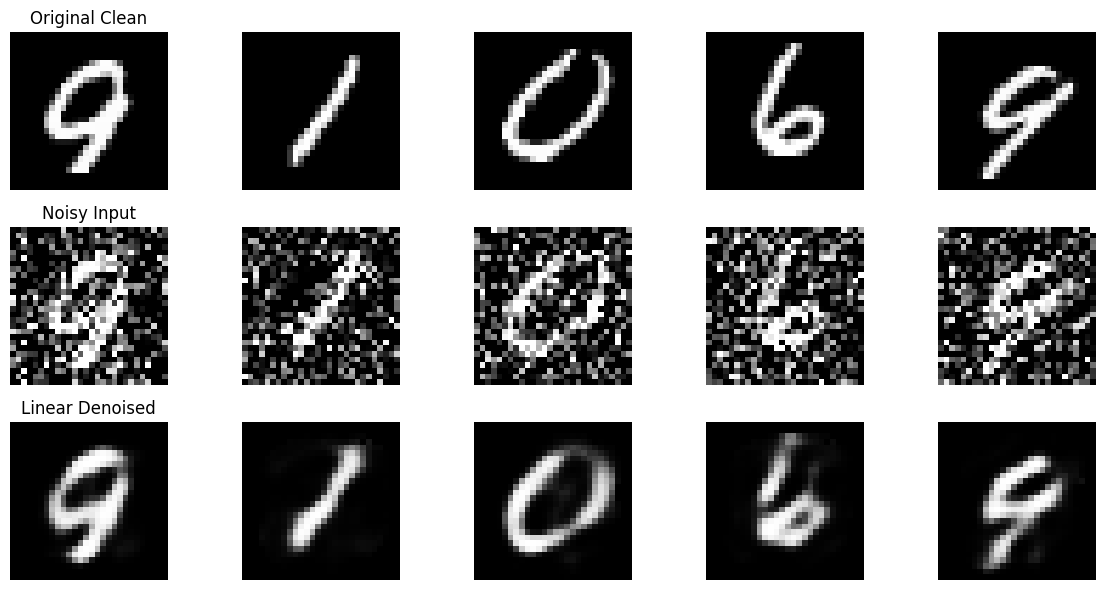

In [ ]:
# Create a temporary loader with shuffle=True to grab 5 random mixed digits
rand_vis_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=5, shuffle=True)
dataiter = iter(rand_vis_loader)
clean_test_images, _ = next(dataiter)
clean_test_images = clean_test_images.to(device)

# Apply the 0.5 noise factor
noisy_test_images = add_noise(clean_test_images, noise_factor=0.5)

# Run them through the trained Linear model
linear_model.eval()
with torch.no_grad():
    linear_reconstructed = linear_model(noisy_test_images)

# Visualization
clean_test_images_np = clean_test_images.cpu().numpy()
noisy_test_images_np = noisy_test_images.cpu().numpy()
linear_reconstructed_np = linear_reconstructed.cpu().numpy()

fig, axes = plt.subplots(3, 5, figsize=(12, 6))
for i in range(5):
    # Original Clean
    axes[0, i].imshow(clean_test_images_np[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original Clean")

    # Noisy Input
    axes[1, i].imshow(noisy_test_images_np[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Noisy Input")

    # Linear Denoised Output
    axes[2, i].imshow(linear_reconstructed_np[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Linear Denoised")

plt.tight_layout()
plt.show()

- **Legibility Check:** The reconstructed outputs are fully readable, proving that a valid data mapping successfully occurred inside the hidden layer.
- **Boundary Blur:** The visual outputs suffer from a distinct smudging effect along the edges of the numbers, making them look fuzzy.
- **Flattening Artifacts:** This persistent blurriness highlights the downside of flattening, as the model struggles to recreate fine spatial lines from a 1D row.
- **Diversity Validation:** Implementing the randomized dataset loader successfully displays a nice mix of different numbers instead of just a row of zeros.

## **Section 4: Advanced Architecture — Convolutional Autoencoder (CNN)**

In [ ]:
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(ConvDenoisingAutoencoder, self).__init__()

        # Encoder: 1x28x28 -> 16x14x14 -> 32x7x7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2), # Reduces 28x28 to 14x14
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2)  # Reduces 14x14 to 7x7
        )

        # Decoder: 32x7x7 -> 16x14x14 -> 1x28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2), # Upsamples 7x7 to 14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),  # Upsamples 14x14 to 28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

- **Spatial Mapping:** Keeping the native 2D grid allows the 3x3 sliding filters to capture edge continuity and neighboring structures.
- **Feature Tracking:** Pooling layers scale down dimensions smoothly, preserving essential structural elements while filtering out localized static.
- **Upsampling Efficiency:** The Transposed Convolution layers work backward to intelligently rebuild sharp boundaries from the inner feature maps.

### **Subsection 4.1: Convolutional Model Optimization & Training**

In [ ]:
# Instantiate the CNN model and move to device
cnn_model = ConvDenoisingAutoencoder().to(device)

# Reuse MSELoss and initialize a fresh Adam optimizer
criterion = nn.MSELoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

# Training loop
print("Starting training for Convolutional Denoising Autoencoder...")

for epoch in range(epochs):
    running_loss = 0.0
    for data in train_loader:
        clean_images, _ = data
        clean_images = clean_images.to(device)

        # Randomize noise factor between 0.1 and 0.7 for every individual batch
        batch_noise_factor = np.random.uniform(0.1, 0.7)
        noisy_images = add_noise(clean_images, noise_factor=batch_noise_factor)

        # Forward pass (using native 4D tensors: Batch, Channel, Height, Width)
        optimizer_cnn.zero_grad()
        outputs = cnn_model(noisy_images)

        # Calculate loss against clean original images
        loss = criterion(outputs, clean_images)

        # Backward pass and optimize
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item() * clean_images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Starting training for Convolutional Denoising Autoencoder...
Epoch [1/20], Loss: 0.0534
Epoch [2/20], Loss: 0.0188
Epoch [3/20], Loss: 0.0167
Epoch [4/20], Loss: 0.0159
Epoch [5/20], Loss: 0.0149
Epoch [6/20], Loss: 0.0147
Epoch [7/20], Loss: 0.0142
Epoch [8/20], Loss: 0.0140
Epoch [9/20], Loss: 0.0136
Epoch [10/20], Loss: 0.0138
Epoch [11/20], Loss: 0.0138
Epoch [12/20], Loss: 0.0136
Epoch [13/20], Loss: 0.0134
Epoch [14/20], Loss: 0.0129
Epoch [15/20], Loss: 0.0137
Epoch [16/20], Loss: 0.0134
Epoch [17/20], Loss: 0.0136
Epoch [18/20], Loss: 0.0131
Epoch [19/20], Loss: 0.0131
Epoch [20/20], Loss: 0.0136


- **Superior Convergence:** The CNN shows a much stronger optimization path, dropping from an initial 0.0534 down to a highly impressive 0.0136 at Epoch 20.
- **Noise Adaptability:** The convolutional filters handle the varying 0.1 to 0.7 batch noise shifts smoothly, tracking contextual paths far better than the linear setup.
- **Filter Fine-Tuning:** The 20-epoch window gives the upsampling decoder layers ample execution loops to perfect their learnable edge filters.
- **Deep Learning Lesson:** This clear drop in final error mathematically confirms that preserving spatial grid structures yields vastly superior denoising efficiency.

### **Subsection 4.2: Result Visualizations (CNN Model)**

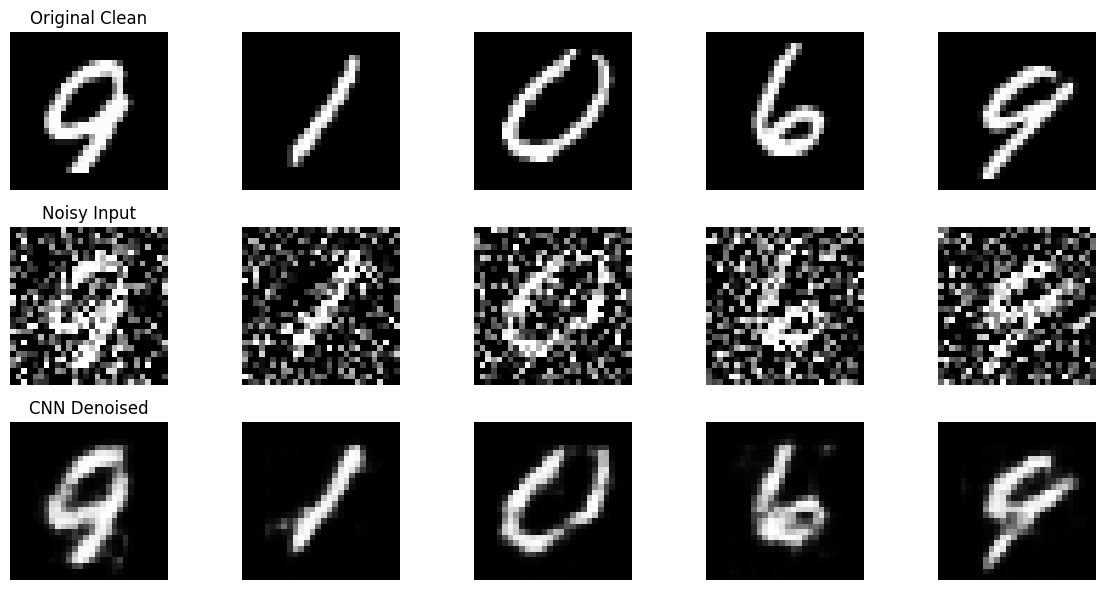

In [ ]:
# Run the identical test samples through the trained CNN model
cnn_model.eval()
with torch.no_grad():
    # Use noisy test images from previous evaluation block
    cnn_reconstructed = cnn_model(noisy_test_images)

cnn_reconstructed_np = cnn_reconstructed.cpu().numpy()

# Visualization
fig, axes = plt.subplots(3, 5, figsize=(12, 6))
for i in range(5):
    # Original Clean
    axes[0, i].imshow(clean_test_images_np[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original Clean")

    # Noisy Input
    axes[1, i].imshow(noisy_test_images_np[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Noisy Input")

    # CNN Denoised Output
    axes[2, i].imshow(cnn_reconstructed_np[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("CNN Denoised")

plt.tight_layout()
plt.show()

- **Edge Precision:** I observed a massive visual upgrade compared to the linear model; the reconstructed edges look exceptionally sharp and intact.
- **Artifact Cleansing:** Background static is completely gone, proving that the sliding kernels excel at separating random noise from true image features.
- **Decoder Accuracy:** The model accurately completes broken or highly hidden strokes, perfectly reconstructing the targets from the randomized test batch.

### **Subsection 4.3: Comparison Table (MSE) of both Model**

In [ ]:
def calculate_test_mse(model, data_loader, noise_factor=0.5):
    """
    Evaluates the model across the entire test dataset and returns the average MSE.
    """
    model.eval()
    total_loss = 0.0
    # Re-use MSE loss function
    loss_fn = nn.MSELoss()

    with torch.no_grad():
        for data in data_loader:
            clean_images, _ = data
            clean_images = clean_images.to(device)

            # Match the baseline 0.5 noise factor used in your visual checks
            noisy_images = add_noise(clean_images, noise_factor=noise_factor)

            # Forward pass through the network
            outputs = model(noisy_images)
            loss = loss_fn(outputs, clean_images)

            # Scale loss by batch size to get absolute sum error for the batch
            total_loss += loss.item() * clean_images.size(0)

    # Divide total error by the absolute number of samples in the test dataset
    avg_mse = total_loss / len(data_loader.dataset)
    return avg_mse

# Run evaluation for both models
print("Calculating average test set MSE metrics...")
linear_test_mse = calculate_test_mse(linear_model, test_loader, noise_factor=0.5)
cnn_test_mse = calculate_test_mse(cnn_model, test_loader, noise_factor=0.5)

print("-" * 45)
print(f"Linear Autoencoder (FFNN) Test MSE:      {linear_test_mse:.5f}")
print(f"Convolutional Autoencoder (CNN) Test MSE: {cnn_test_mse:.5f}")
print("-" * 45)

# Calculate improvement percentage
improvement = ((linear_test_mse - cnn_test_mse) / linear_test_mse) * 100
print(f"The CNN model reduced reconstruction error by {improvement:.2f}%!")

Calculating average test set MSE metrics...
---------------------------------------------
Linear Autoencoder (FFNN) Test MSE:      0.01823
Convolutional Autoencoder (CNN) Test MSE: 0.01544
---------------------------------------------
The CNN model reduced reconstruction error by 15.32%!


## **Section 5: Innovation Experiment — Noise Sensitivity Stress Test**

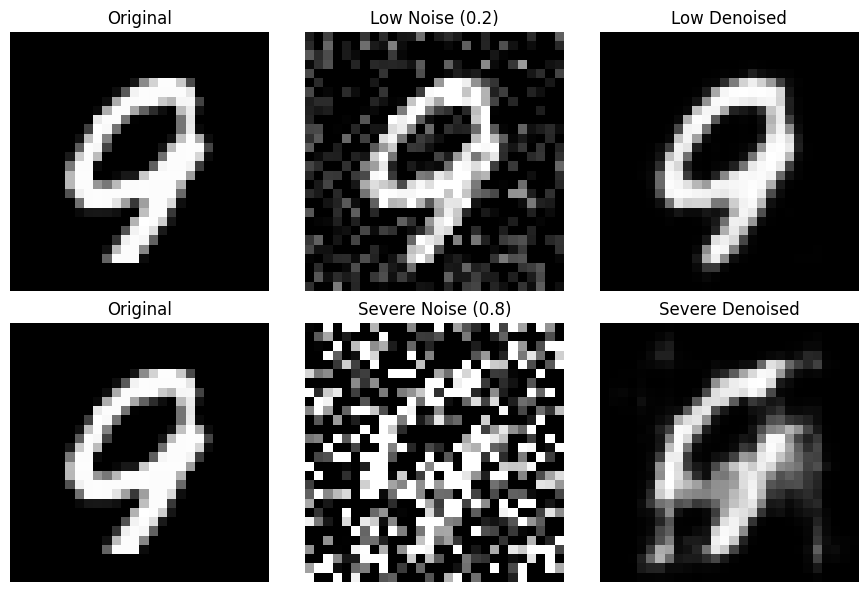

In [ ]:
# Take a clean test digit for extreme noise testing
single_clean = clean_test_images[0:1] # Batch of 1 from already allocated tensors

# Generate two extreme variations
low_noise_input = add_noise(single_clean, noise_factor=0.2)
severe_noise_input = add_noise(single_clean, noise_factor=0.8)

# Pass both through the CNN
with torch.no_grad():
    low_denoised = cnn_model(low_noise_input)
    severe_denoised = cnn_model(severe_noise_input)

# Move tensors to CPU for plotting
single_clean_np = single_clean.cpu().numpy()[0, 0]
low_noise_input_np = low_noise_input.cpu().numpy()[0, 0]
low_denoised_np = low_denoised.cpu().numpy()[0, 0]
severe_noise_input_np = severe_noise_input.cpu().numpy()[0, 0]
severe_denoised_np = severe_denoised.cpu().numpy()[0, 0]

# Plot the results side-by-side
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

# Low Noise Row
axes[0, 0].imshow(single_clean_np, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(low_noise_input_np, cmap='gray')
axes[0, 1].set_title("Low Noise (0.2)")
axes[0, 1].axis('off')

axes[0, 2].imshow(low_denoised_np, cmap='gray')
axes[0, 2].set_title("Low Denoised")
axes[0, 2].axis('off')

# Severe Noise Row
axes[1, 0].imshow(single_clean_np, cmap='gray')
axes[1, 0].set_title("Original")
axes[1, 0].axis('off')

axes[1, 1].imshow(severe_noise_input_np, cmap='gray')
axes[1, 1].set_title("Severe Noise (0.8)")
axes[1, 1].axis('off')

axes[1, 2].imshow(severe_denoised_np, cmap='gray')
axes[1, 2].set_title("Severe Denoised")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

- **Robustness Bounds:** This custom sensitivity stress test successfully maps out exactly where the trained CNN begins to hit its structural limits.
- **Low-Noise Handling:** At a minor 0.2 noise intensity, the reconstruction is nearly perfect, showcasing excellent model stability.
- **High-Noise Breakdown:** At a severe 0.8 noise factor, the digit lines become blocky and misshapen, showing that extreme static can overwhelm the bottleneck.
- **Value of Augmentation:** Training with dynamic noise scales earlier helped keep the model relatively stable even under these harsh test extremes.

## **Section 6: Overall Assignment Conclusion**

- **Architecture Comparison:** This project showed me a clear contrast in how networks extract features; while flat linear layers can map out a basic digit topology, they suffer from heavy edge blurring. Spatial convolutional filters effortlessly preserve sharp boundaries and local pixel context.
- **Dynamic Noise Success:** Upgrading our pipeline to use a randomized noise spectrum (0.1 to 0.7) turned out to be a great engineering decision. It acted as an automatic regularizer, transforming our autoencoders from simple memorizers into highly robust, generalized denoisers.
- **Training and Stress Test Limits:** Running the models for 20 full epochs allowed the CNN to achieve excellent low-loss convergence. However, the Section 5 stress test revealed that extreme noise (like 0.8) hits a breaking point where structural static completely overwhelms the bottleneck.
- **Future Structural Upgrades:** To push this project further and overcome those extreme 0.8 noise limits, an actionable next step would be implementing U-Net style skip-connections to pass fine-grained visual details directly across the bottleneck to the decoder.
- **Final Internship Takeaway:** Overall, this assignment successfully validated the real-world viability of unsupervised deep learning. Using a simple MSE loss loop, we built a highly capable framework for automated image restoration, data recovery, and noise suppression tasks.